# Step 4 Model Implementation

In [ ]:
from sklearn.model_selection import train_test_split

# Define predictors and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (25601, 10)
Testing set: (6401, 10)

Training target distribution:
is_fraud
0    0.518417
1    0.481583
Name: proportion, dtype: float64

Testing target distribution:
is_fraud
0    0.518357
1    0.481643
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        log_pred,
        log_prob
    )
)

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        dt_pred,
        dt_prob
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        'XGBoost',
        y_test,
        xgb_pred,
        xgb_prob
    )
)

results.append(
    evaluate_model(
        'SVM',
        y_test,
        svm_pred,
        svm_prob
    )
)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by='F1-Score',
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.740041,0.747126,0.695751,0.720524,0.820679
4,SVM,0.740978,0.753108,0.687642,0.718888,0.818330
3,XGBoost,0.735354,0.738742,0.697048,0.717290,0.812999
2,Random Forest,0.731761,0.733904,0.695102,0.713976,0.805803
1,Decision Tree,0.649274,0.637197,0.631203,0.634186,0.648634


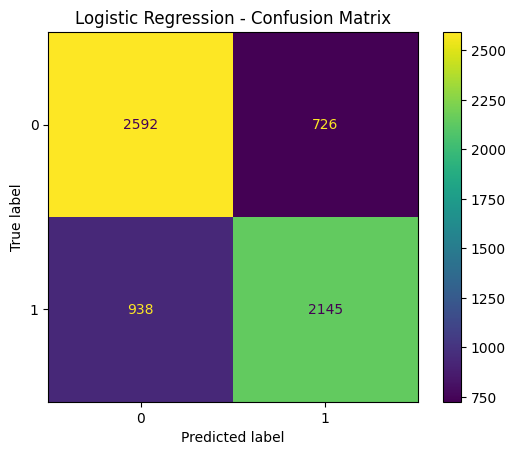

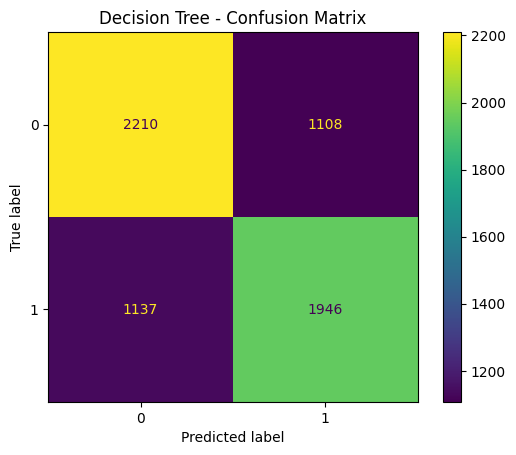

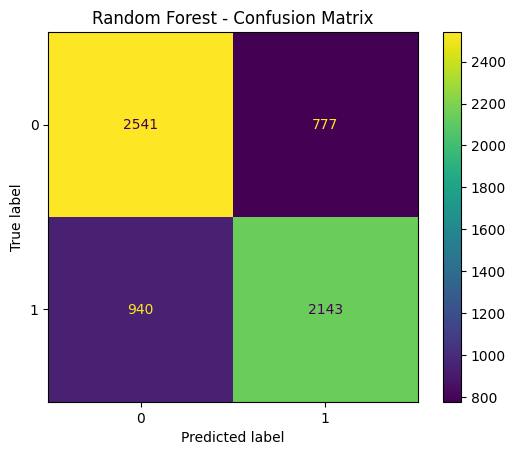

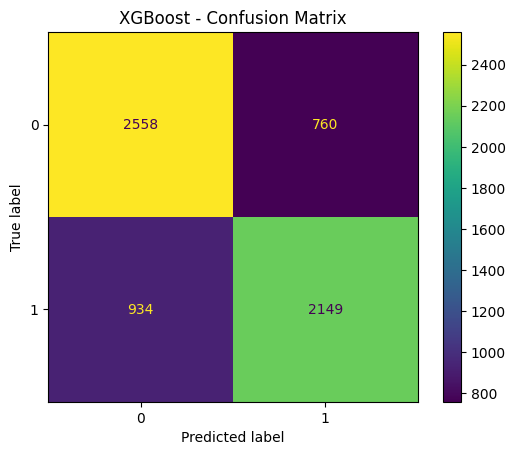

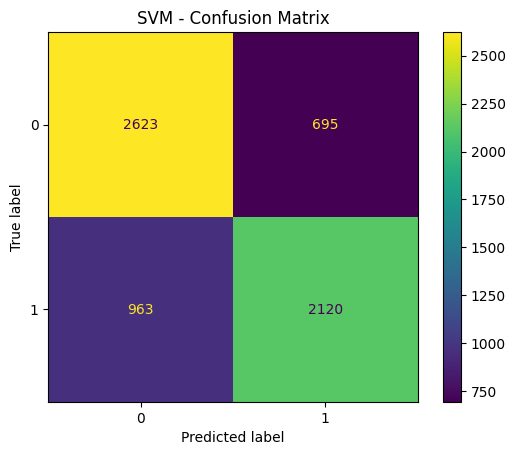

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models_predictions = {
    'Logistic Regression': log_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'SVM': svm_pred
}

for name, predictions in models_predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.show()

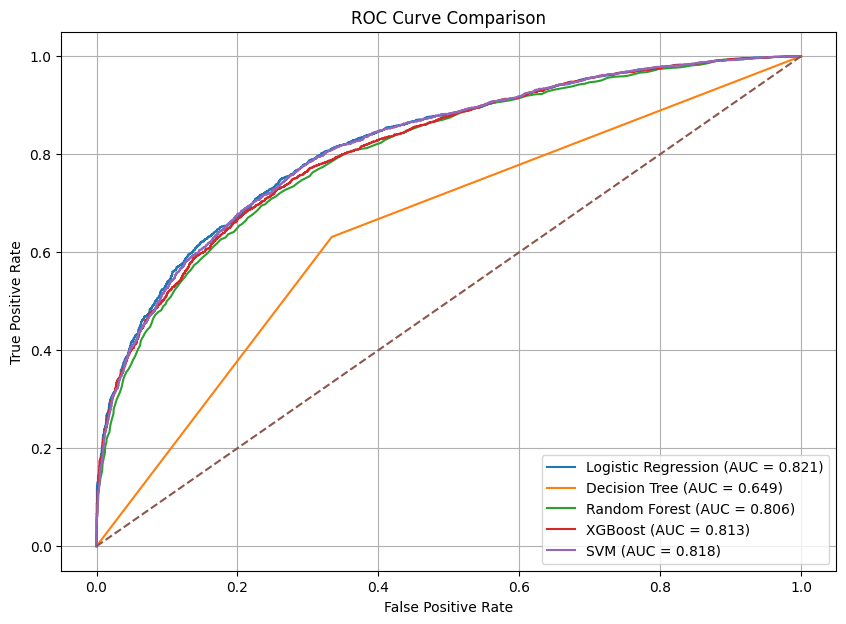

In [ ]:
from sklearn.metrics import roc_curve

model_probabilities = {
    'Logistic Regression': log_prob,
    'Decision Tree': dt_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob,
    'SVM': svm_prob
}

plt.figure(figsize=(10, 7))

for name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Model Implementation and Performance Comparison

Five supervised machine learning algorithms were implemented to predict fraudulent credit card transactions: Logistic Regression, Decision Tree, Random Forest, XGBoost, and Support Vector Machine (SVM). The models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics were selected because fraud detection requires an appropriate balance between correctly identifying fraudulent transactions and minimizing false fraud alerts.

The results showed that Logistic Regression provided the strongest overall performance among the models tested. It achieved an accuracy of 74.00%, precision of 74.71%, recall of 69.58%, F1-score of 72.05%, and ROC-AUC of 82.07%. In particular, its highest F1-score and ROC-AUC indicate that Logistic Regression provided the best balance between identifying fraudulent transactions and distinguishing fraudulent transactions from legitimate ones.

SVM achieved the highest accuracy at 74.10% and the highest precision at 75.31%. However, its recall was slightly lower at 68.76%, indicating that it identified a slightly smaller proportion of fraudulent transactions compared with Logistic Regression and XGBoost. XGBoost achieved the highest recall at 69.70%, which indicates that it detected the greatest proportion of fraudulent transactions among the models evaluated. However, its F1-score of 71.73% and ROC-AUC of 81.30% were lower than those of Logistic Regression.

Random Forest produced moderate performance, with an accuracy of 73.18%, precision of 73.39%, recall of 69.51%, F1-score of 71.40%, and ROC-AUC of 80.58%. Although its performance was relatively competitive, it did not outperform the other ensemble and classification approaches. Decision Tree produced the weakest results, particularly in terms of ROC-AUC, which was only 64.86%, indicating substantially weaker discriminative performance.

Overall, Logistic Regression was selected as the leading candidate model based on its highest F1-score and ROC-AUC. Although XGBoost achieved marginally higher recall and SVM achieved marginally higher accuracy and precision, Logistic Regression provided the most balanced performance across the principal evaluation metrics. The results therefore suggest that a relatively simple and interpretable model was sufficient to achieve competitive predictive performance for the fraud detection task.


## Hyperparameter Tuning using Logistic Regression and XGBoost

In [ ]:
# ============================================================
# STEP 4.9: HYPERPARAMETER TUNING
# Logistic Regression
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter search space
log_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000]
}

# Create base model
log_base = LogisticRegression(
    random_state=42
)

# Randomized search
log_search = RandomizedSearchCV(
    estimator=log_base,
    param_distributions=log_param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on training data only
log_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(log_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(log_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression Parameters:
{'solver': 'liblinear', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 0.01}

Best Cross-Validation F1-Score:
0.7352326450095445


In [ ]:
# ============================================================
# XGBoost Hyperparameter Tuning
# ============================================================

from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best Cross-Validation F1-Score:
0.7275231419243299


In [ ]:
# ============================================================
# Evaluate Tuned Models
# ============================================================

# Best Logistic Regression
best_log_model = log_search.best_estimator_

log_tuned_pred = best_log_model.predict(X_test)
log_tuned_prob = best_log_model.predict_proba(X_test)[:, 1]


# Best XGBoost
best_xgb_model = xgb_search.best_estimator_

xgb_tuned_pred = best_xgb_model.predict(X_test)
xgb_tuned_prob = best_xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

tuned_results = pd.DataFrame([
    {
        'Model': 'Tuned Logistic Regression',
        'Accuracy': accuracy_score(y_test, log_tuned_pred),
        'Precision': precision_score(y_test, log_tuned_pred),
        'Recall': recall_score(y_test, log_tuned_pred),
        'F1-Score': f1_score(y_test, log_tuned_pred),
        'ROC-AUC': roc_auc_score(y_test, log_tuned_prob)
    },
    {
        'Model': 'Tuned XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_tuned_pred),
        'Precision': precision_score(y_test, xgb_tuned_pred),
        'Recall': recall_score(y_test, xgb_tuned_pred),
        'F1-Score': f1_score(y_test, xgb_tuned_pred),
        'ROC-AUC': roc_auc_score(y_test, xgb_tuned_prob)
    }
])

display(tuned_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.740509,0.732353,0.726889,0.729611,0.818345
1,Tuned XGBoost,0.740197,0.745845,0.698670,0.721487,0.817466


In [ ]:
baseline_results = results_df.copy()

comparison_results = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True
)

display(
    comparison_results.sort_values(
        by='F1-Score',
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Tuned Logistic Regression,0.740509,0.732353,0.726889,0.729611,0.818345
6,Tuned XGBoost,0.740197,0.745845,0.698670,0.721487,0.817466
0,Logistic Regression,0.740041,0.747126,0.695751,0.720524,0.820679
4,SVM,0.740978,0.753108,0.687642,0.718888,0.818330
3,XGBoost,0.735354,0.738742,0.697048,0.717290,0.812999
2,Random Forest,0.731761,0.733904,0.695102,0.713976,0.805803
1,Decision Tree,0.649274,0.637197,0.631203,0.634186,0.648634


### Final Model Selection

Based on the comparative evaluation of the supervised machine learning models, the tuned Logistic Regression model was selected as the final model for the fraud detection task. The tuned Logistic Regression achieved an accuracy of 74.05%, precision of 73.24%, recall of 72.69%, F1-score of 72.96%, and ROC-AUC of 81.83%.

Among the models evaluated, the tuned Logistic Regression achieved the highest F1-score and recall. The F1-score indicates a balanced performance between precision and recall, while the higher recall indicates that the model was able to identify a greater proportion of fraudulent transactions. Although the Support Vector Machine achieved slightly higher accuracy and precision, its recall and F1-score were lower. Similarly, XGBoost achieved competitive performance but did not exceed the tuned Logistic Regression in terms of F1-score.

Hyperparameter tuning improved the Logistic Regression F1-score from 72.05% to 72.96%, indicating a modest improvement in the balance between precision and recall. The tuned Logistic Regression was therefore selected as the final model based on its overall predictive performance and suitability for the fraud detection objective.

The final model provides a reasonable balance between detecting fraudulent transactions and limiting incorrect classifications. The selected model and its corresponding performance metrics will serve as the basis for the subsequent interpretation and discussion of the machine learning results.


Saving Tuned Loistic Regression as best model

In [ ]:
best_log_model = log_search.best_estimator_

In [ ]:
import os
import joblib

# Create the models directory
os.makedirs("models", exist_ok=True)

# Save the tuned Logistic Regression model
joblib.dump(
    best_log_model,
    "models/tuned_logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import joblib

joblib.dump(
    best_log_model,
    "models/tuned_logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.
